# Predicting Remaining Useful Life (RUL) of a Turbofan Engine

**NASA C-MAPSS dataset - subset FD001** · complete machine-learning walkthrough

This notebook follows the same pipeline as the `src/` scripts:

```
Data loading → Exploration → Preprocessing → RUL target → Feature selection
→ Train/validation split → ML model → Prediction → Evaluation
```

Two tree-based models (Random Forest and Gradient Boosting) are trained,
compared on validation engines, and the better one is evaluated on the test set.

## Setup

In [1]:
# ------------------------------------------------------------------
# Setup: make the src/ modules importable and configure plotting
# ------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# When the notebook is run from the notebooks/ folder, add the project
# root to sys.path so `from src import ...` works.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import data_preprocessing as dp

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

print("Project root :", ROOT)
print("Data folder  :", dp.DATA_DIR)

Project root : /home/user/turbofan-rul-prediction
Data folder  : /home/user/turbofan-rul-prediction/data


## 1. Load the dataset

Each row is one engine at one operational cycle, with 26 columns:

| columns | meaning |
|---|---|
| `unit` | engine id |
| `cycle` | operational cycle number |
| `setting1-3` | operational settings |
| `sensor1-21` | sensor measurements |

The files are space-separated with a trailing space on each line; the loader
in `src/data_preprocessing.py` handles that.

In [2]:
train = dp.load_train_data()
test = dp.load_test_data()
rul = dp.load_test_rul()

print(f"Training set : {train.shape[0]:>6} rows x {train.shape[1]} columns  ({train['unit'].nunique()} engines)")
print(f"Test set     : {test.shape[0]:>6} rows x {test.shape[1]} columns  ({test['unit'].nunique()} engines)")
print(f"RUL values   : {rul.shape[0]:>6} values (one per test engine)")
print()
print("Columns:", list(train.columns))

Training set :  20631 rows x 26 columns  (100 engines)
Test set     :  13096 rows x 26 columns  (100 engines)
RUL values   :    100 values (one per test engine)

Columns: ['unit', 'cycle', 'setting1', 'setting2', 'setting3', 'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21']


In [3]:
# First rows of the training set
train.head()

,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Missing values and variance check

1. **Missing values** - the C-MAPSS files are complete, but we check anyway.
2. **Variance check** - a constant column (variance ≈ 0) carries no
   information for the model, so such sensors/settings are removed.

In [4]:
# --- missing values ---
missing = dp.report_missing_values(train)
print(f"Columns with missing values: {len(missing)}")
print(missing if len(missing) else "None - the dataset is complete.")

# --- variance check: constant / near-constant columns ---
dropped, variances = dp.find_low_variance_columns(
    train, dp.SETTING_COLUMNS + dp.SENSOR_COLUMNS
)
print(f"\nConstant / near-constant columns (variance < {dp.VARIANCE_THRESHOLD}):")
variances.loc[dropped].round(6)

Columns with missing values: 0
None - the dataset is complete.

Constant / near-constant columns (variance < 0.01):


setting1    0.000005
setting2    0.000000
setting3    0.000000
sensor1     0.000000
sensor5     0.000000
sensor6     0.000002
sensor8     0.005039
sensor10    0.000000
sensor13    0.005172
sensor15    0.001407
sensor16    0.000000
sensor18    0.000000
sensor19    0.000000
dtype: float64

## 3. Generate the RUL target (training set only)

Training engines run **until failure**, so we know each engine's last cycle.
For every row of an engine:

$$\text{RUL} = \text{max cycle of the engine} - \text{current cycle}$$

A row recorded 10 cycles before failure gets RUL = 10; the very last row
gets RUL = 0. (Optionally the target can be clipped at a constant value -
see `RUL_CAP` in `src/data_preprocessing.py`.)

In [5]:
train = dp.add_rul_column(train)

# Sanity check: for engine 1, RUL must count down to 0 in its last cycle
train[train["unit"] == 1][["unit", "cycle", "rul"]].tail(8)

,unit,cycle,rul
184,1,185,7
185,1,186,6
186,1,187,5
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


## 4. Feature selection

The features used by the model are:

- `cycle` - the age of the engine (always kept: strong, legitimate signal)
- every sensor/setting whose variance survived the check in section 2

In [6]:
features, dropped = dp.select_features(train)

print(f"Features kept ({len(features)}): {features}")
print(f"Columns dropped ({len(dropped)}): {dropped}")

Features kept (12): ['cycle', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor9', 'sensor11', 'sensor12', 'sensor14', 'sensor17', 'sensor20', 'sensor21']
Columns dropped (13): ['setting1', 'setting2', 'setting3', 'sensor1', 'sensor5', 'sensor6', 'sensor8', 'sensor10', 'sensor13', 'sensor15', 'sensor16', 'sensor18', 'sensor19']


## 5. Exploratory Data Analysis

**5.1 RUL distribution** - how many records have each RUL value. FD001
engines typically run ~130-360 cycles, so RUL is spread over that range.

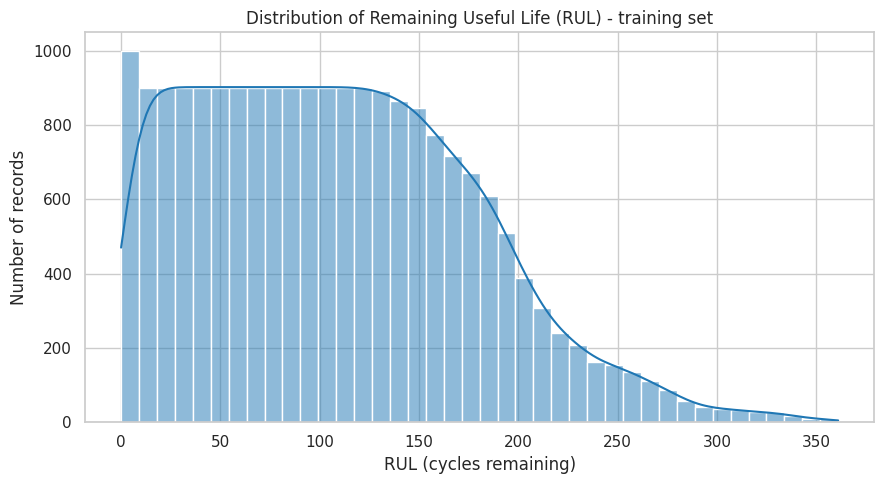

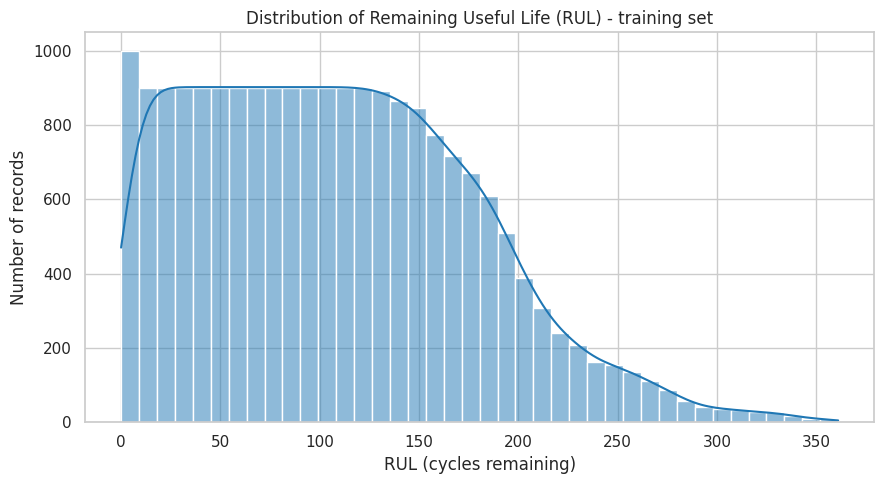

In [7]:
fig = dp.plot_rul_distribution(train, dp.PLOTS_DIR / "rul_distribution.png")
fig

**5.2 Sensor trends vs cycle** - healthy engines show drifting sensors
as they degrade. Most selected sensors drift visibly (up or down) as the
cycle number grows, which is exactly the signal the model should learn.

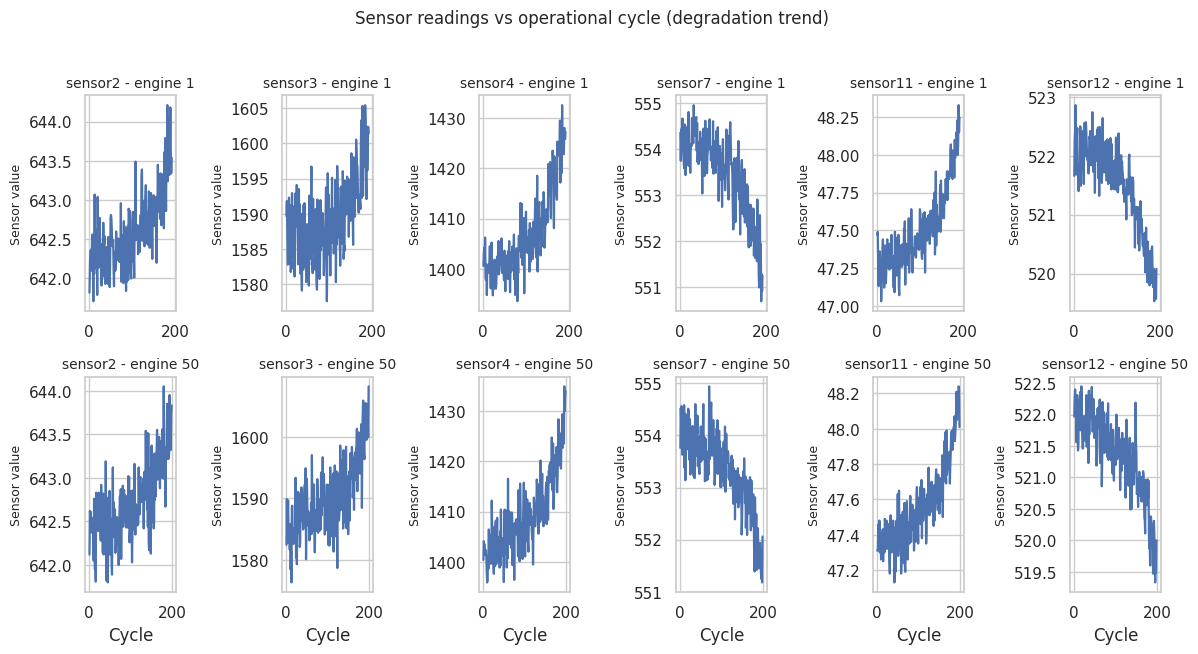

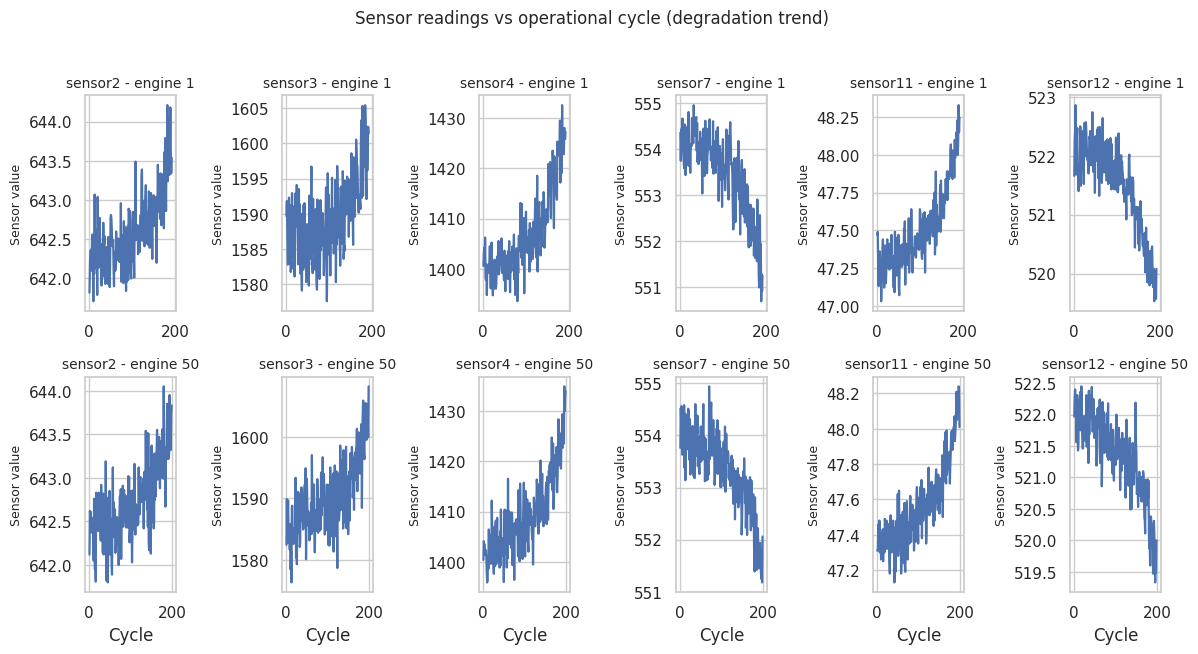

In [8]:
fig = dp.plot_sensor_trends(
    train,
    sensors=["sensor2", "sensor3", "sensor4", "sensor7", "sensor11", "sensor12"],
    engine_ids=(1, 50),   # two example engines
    save_path=dp.PLOTS_DIR / "sensor_trends.png",
)
fig

**5.3 Correlation with RUL** - sensors with a strong (positive or
negative) correlation with RUL are the most useful predictors. `cycle` is
negatively correlated with RUL, as expected.

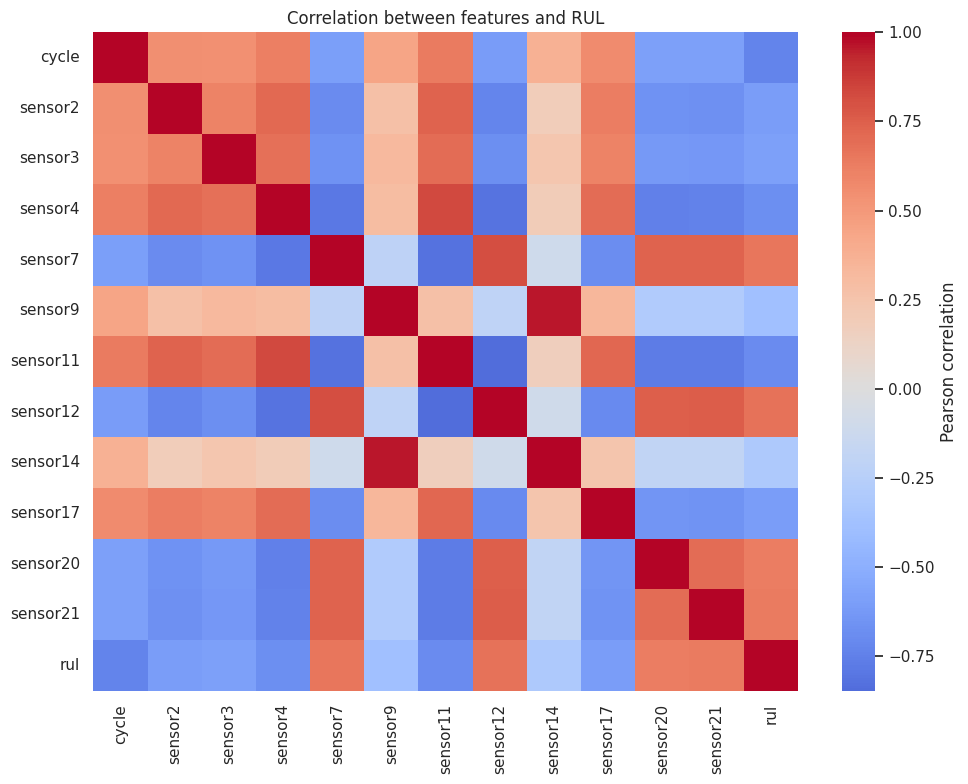

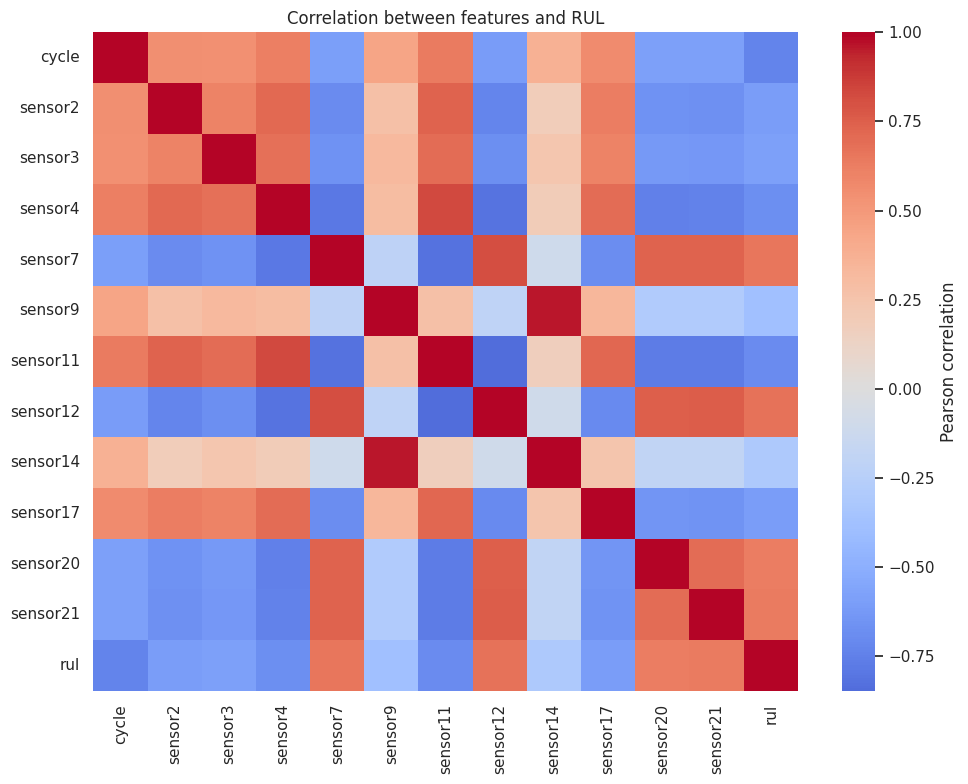

In [9]:
fig = dp.plot_correlation_heatmap(train, features, dp.PLOTS_DIR / "correlation_heatmap.png")
fig

## 6. Train / validation split (by engine, not by row!)

If we split rows randomly, different cycles of the **same engine** would end
up in both sets and the validation score would be unrealistically good
(data leakage). Instead we split on unique engine ids, so the validation
engines are **completely unseen** during training.

In [10]:
from src.train_model import split_by_unit

X_train, X_val, y_train, y_val, train_units, val_units = split_by_unit(train, features)
print(f"Training engines   : {len(train_units):>3}  ({X_train.shape[0]:>5} rows)")
print(f"Validation engines : {len(val_units):>3}  ({X_val.shape[0]:>5} rows)")
print(f"Feature matrix     : {X_train.shape}")

Training engines   :  80  (16561 rows)
Validation engines :  20  ( 4070 rows)
Feature matrix     : (16561, 12)


## 7. Train and compare the two models

- **Random Forest** - 100 trees, each trained on a random sample of rows/features
- **Gradient Boosting** - 100 shallow trees added one after another, each
  fixing the errors of the previous ones

Both are wrapped in a `Pipeline` with a `StandardScaler` (not strictly needed
for trees, but it keeps the pipeline consistent if other models are added).

In [11]:
from src.train_model import build_models, evaluate_model

rows = []
for name, pipe in build_models().items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    m = evaluate_model(y_val, pred)
    rows.append({"model": name, **m})
    print(f"{name:<18} MAE={m['MAE']:6.2f}  RMSE={m['RMSE']:6.2f}  R2={m['R2']:.3f}")

compare = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
compare

Random Forest      MAE= 24.14  RMSE= 31.82  R2=0.765


Gradient Boosting  MAE= 22.87  RMSE= 29.90  R2=0.793


,model,MAE,RMSE,R2
0,Gradient Boosting,22.870322,29.898606,0.792601
1,Random Forest,24.135479,31.824520,0.765021


**Reading the table:** MAE / RMSE are errors in cycles - lower is better.
R² is the share of RUL variance the model explains - closer to 1 is better.
The better model is the one with the lowest RMSE.

## 8. Select the best model and retrain on ALL training data

Now that we know which model is better, we retrain it on the **complete**
training set (train + validation engines) - the model we will actually use
for the test set - and save it to `outputs/best_model.joblib`.

In [12]:
import joblib

best_name = compare.iloc[0]["model"]
print("Best model on validation:", best_name)

best_pipe = build_models()[best_name]
best_pipe.fit(train[features], train["rul"])
joblib.dump(best_pipe, dp.OUTPUT_DIR / "best_model.joblib")

# Most useful features according to the best model
importances = pd.Series(best_pipe.named_steps["model"].feature_importances_,
                        index=features)
importances.sort_values(ascending=False).head(10).round(3)

Best model on validation: Gradient Boosting


cycle       0.676
sensor11    0.093
sensor4     0.081
sensor12    0.041
sensor9     0.026
sensor7     0.026
sensor21    0.015
sensor14    0.012
sensor2     0.012
sensor20    0.008
dtype: float64

## 9. Test set evaluation

For every test engine we take its **last recorded cycle** (that is the
moment at which we must predict the RUL), predict, and compare against the
true RUL values from `RUL_FD001.txt`.

In [13]:
X_test, y_true, test_final = dp.prepare_test(test, rul, features)
y_pred = best_pipe.predict(X_test)

m = evaluate_model(y_true, y_pred)
print(f"Test engines predicted: {len(y_pred)}")
pd.DataFrame([m], index=["test set"]).round(3)

Test engines predicted: 100


,MAE,RMSE,R2
test set,18.252,25.229,0.631


- **MAE** - average of `|actual - predicted|`: on average the prediction is
  off by this many cycles.
- **RMSE** - like MAE but penalises large errors more (errors are squared
  before averaging). Always ≥ MAE.
- **R²** - share of the variance in the true RUL explained by the model
  (1.0 = perfect, 0.0 = as good as predicting the mean).

In [14]:
results = pd.DataFrame({
    "engine_id": test_final["unit"].values,
    "actual_rul": y_true.values,
    "predicted_rul": np.round(y_pred, 1),
    "abs_error": np.round(np.abs(y_true.values - y_pred), 1),
})
results.head(10)

,engine_id,actual_rul,predicted_rul,abs_error
0,1,112,185.6,73.6
1,2,98,139.8,41.8
2,3,69,44.7,24.3
3,4,82,82.0,0.0
4,5,91,89.2,1.8
5,6,93,107.7,14.7
6,7,91,96.6,5.6
7,8,95,76.2,18.8
8,9,111,144.1,33.1
9,10,96,99.6,3.6


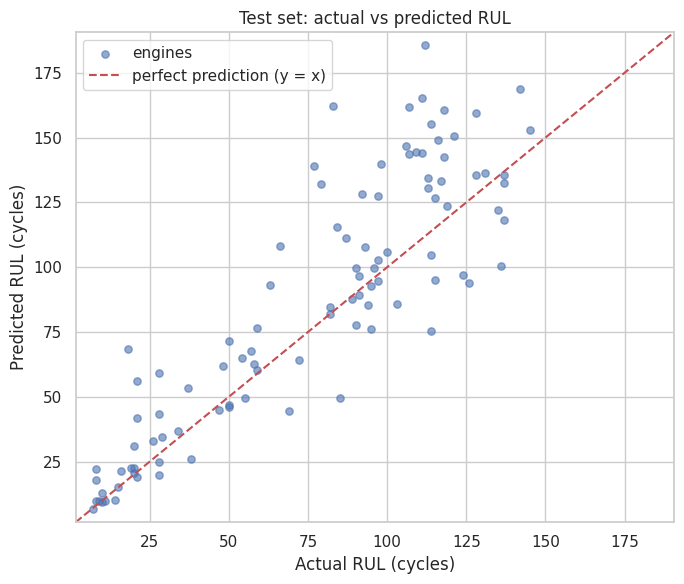

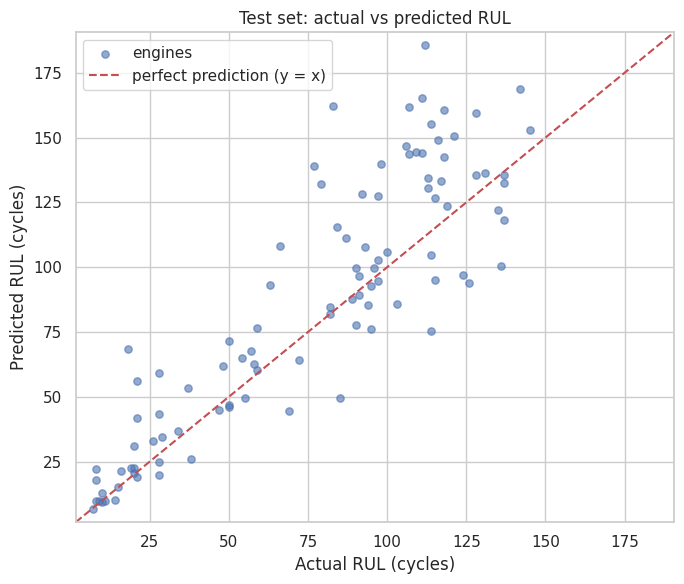

In [15]:
from src.train_model import plot_actual_vs_predicted

fig = plot_actual_vs_predicted(
    y_true, y_pred,
    "Test set: actual vs predicted RUL",
    dp.PLOTS_DIR / "test_actual_vs_predicted.png",
)
fig

## 10. Summary

- The pipeline loads C-MAPSS FD001, drops 13 constant / near-constant
  columns and keeps 12 features (`cycle` + 11 sensors).
- RUL is generated as `max cycle - current cycle` per training engine.
- An **engine-wise split** avoids data leakage.
- Gradient Boosting beats Random Forest on the validation engines and is
  the selected model.
- Points in the scatter plot close to the red `y = x` line are well
  predicted; the model is most uncertain for engines early in their life.

The same results can be reproduced with the scripts:
`python src/data_preprocessing.py`, `python src/train_model.py`,
`python src/evaluate_model.py`.